In [1]:
import PMTreco as rec
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import os
import DRS4Correction as cor

In [2]:
# LNGS RUNS
runs = np.arange(7783, 7787+1, 1)

# LNF RUNS
runs  = [3951]

In [3]:
reco0 = rec.PMTreco(runs) ## to be adaptaded to the cygnolib

3951


In [4]:
listwfs, listSIC = cor.GetInfoForCorrections(runs)

run =  3951


In [5]:
import cygno as cy
mfile = cy.open_mid(run=3951, path='./tmp/', cloud=False, tag='', verbose=False)

In [6]:
odb = cy.get_bor_odb(mfile)

In [7]:
#odb.data['Configurations']

In [8]:
len(listSIC)

2972

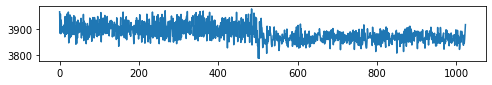

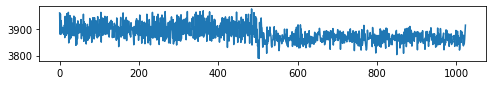

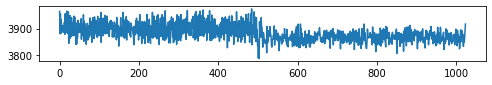

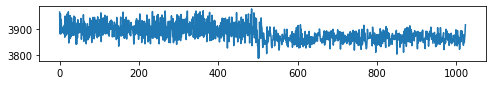

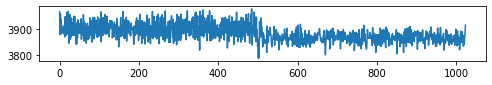

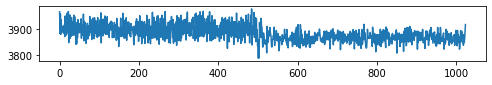

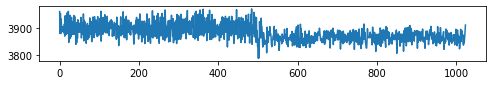

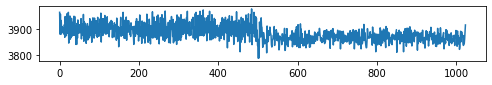

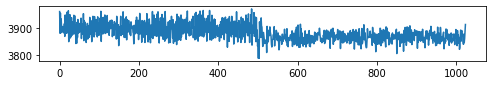

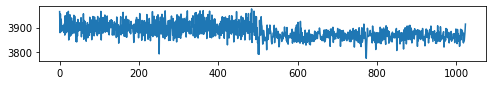

In [9]:
ch =1
for i in range(0, 10):
    plt.figure(figsize=(8,1))
    plt.plot(np.arange(0, 1024, 1), listwfs[ch][i])
    #plt.hlines(np.mean(ret[ch])+30, 0, 1024, color = 'red')
    #plt.xlim(1000, 1024)
    plt.show()

In [10]:
ret = cor.CellCorrection(listwfs)

Saving recomputed tables...


In [11]:
ret = cor.nSampleCorrection(ret, listSIC)

Saving recomputed tables...


In [12]:
ret = cor.PeakCorrection(ret)



2971



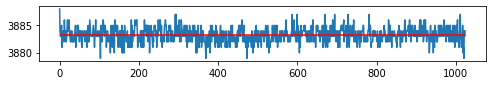

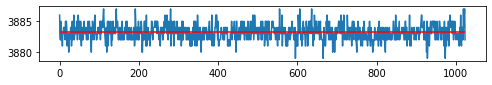

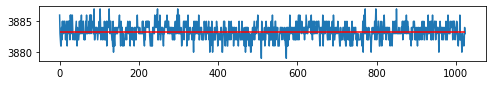

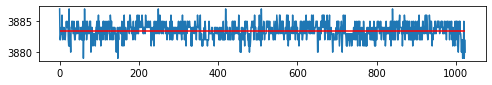

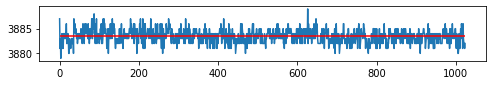

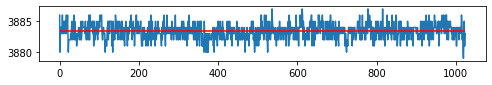

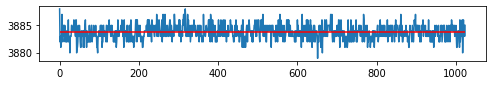

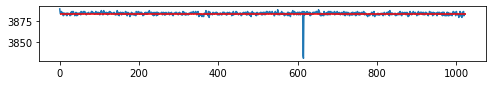

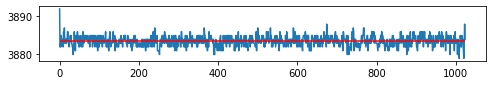

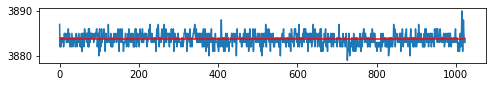

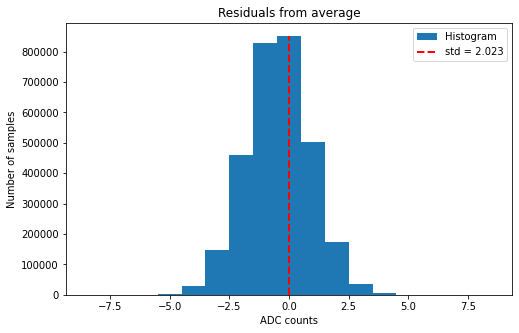

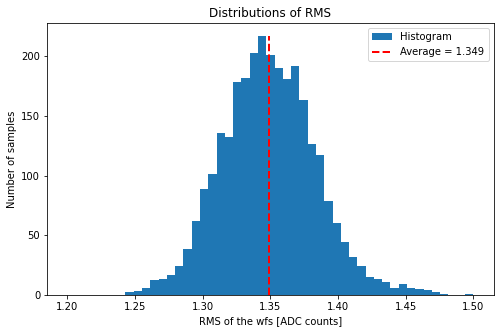

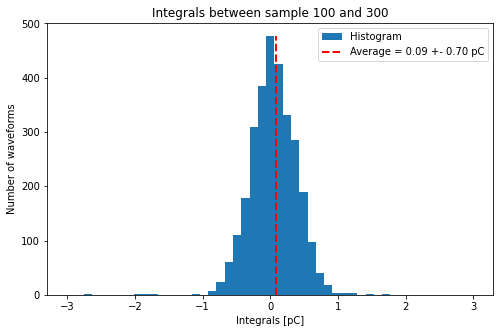

In [13]:
ch =1
stds = np.zeros(len(ret[ch]))
integrals = np.zeros(len(ret[ch]))
for i in range(len(ret[ch])):
    stds[i] = np.std(ret[ch][i])
    integrals[i] = np.sum(ret[ch][i][100:300]- np.mean(ret[ch][i][:100]))*1000*4/3/50/4096 # pC
    
    

    
    
for i in range(0, 10):
    plt.figure(figsize=(8,1))
    plt.plot(np.arange(0, 1024, 1), ret[ch][i], zorder = 0)
    plt.hlines(np.mean(ret[ch][i]), 0, 1024, color = 'red', zorder = 1)
    #plt.xlim(1000, 1024)
    plt.show()
    
plt.figure(figsize = (8,5))
y, x, _ = plt.hist((ret[ch].flat - np.mean(ret[ch].flat)), bins = np.arange(-8.5, 9.5, 1), label = 'Histogram')
plt.vlines(np.mean((ret[ch].flat - np.mean(ret[ch].flat))), 0, np.max(y), color = 'red',
          linestyle = '--', linewidth = 2,
           label = 'std = {0:.3f}'.format(np.std((ret[ch].flat - np.mean(ret[ch].flat)))))
plt.title('Residuals from average')
plt.ylabel('Number of samples')
plt.xlabel('ADC counts')
plt.legend()
plt.show()


plt.figure(figsize = (8,5))
y, x, _ = plt.hist(stds, bins = np.linspace(1.2, 1.5, 50), label = 'Histogram')
plt.vlines(np.mean(stds[np.where(stds<1.5)]), 0, np.max(y), color = 'red',
          linestyle = '--', linewidth = 2,
           label = 'Average = {0:.3f}'.format(np.mean(stds[np.where(stds<1.5)])))
plt.title('Distributions of RMS')
plt.ylabel('Number of samples')
plt.xlabel('RMS of the wfs [ADC counts]')
plt.legend()
plt.show()



plt.figure(figsize = (8,5))
y, x, _ = plt.hist(integrals, bins = np.linspace(-3, 3, 50), label = 'Histogram')
plt.vlines(np.mean(integrals[np.where(np.abs(integrals)<30)]), 0, np.max(y), color = 'red',
          linestyle = '--', linewidth = 2,
           label = 'Average = {0:.2f} +- {1:.2f} pC'.format(np.mean(integrals[np.where(np.abs(integrals)<30)]),
                                                         np.std(integrals[np.where(np.abs(integrals)<30)])
                                                        ))
plt.title('Integrals between sample 100 and 300')
plt.ylabel('Number of waveforms')
plt.xlabel('Integrals [pC]')
plt.legend()
plt.show()